# Notebook 29: Listwise Differential Graph-Bayes-MLP Adjudicator

Notebook 28 showed that prospective multi-branching can recover some wrong live trajectories, but its final resolver only scored branch top-1 and pseudo top-1 candidates. Post-hoc analysis showed that several remaining correct diagnoses were already present inside base or branch ranked differentials.

This notebook keeps Notebook 28's live evidence acquisition and branch execution frozen. It adds an offline final listwise adjudicator over ranked differential candidates using train/validate-derived graph, Bayesian, and MLP candidate scoring. No API calls are made.

Control question:

> Can a mathematical listwise evidence ledger safely promote ranked differential candidates that the prior branch resolver never scored?

## 1. Utility Functions

In [1]:
from __future__ import annotations

import ast
import json
import math
import time
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 30)

ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "scripts" / "download_ddxplus.py").exists()),
    Path.cwd(),
)
DATASET_ROOT = ROOT / "dataset"

NOTEBOOK28_ROOT = ROOT / "artifacts" / "trajectory_replicates" / "mlp_gated_confounder_graph_bayes_branching_49case_v1"
NOTEBOOK13_ROOT = ROOT / "artifacts" / "sequential_hybrid_mlp_feedback" / "selected_stop_live_confirmation_49case_v1"
NOTEBOOK24_ROOT = ROOT / "artifacts" / "graph_algorithmic_ledger" / "live_graph_bayes_rescue_confirmation_49case_v1"
GRAPH_ROOT = ROOT / "artifacts" / "graph_algorithmic_ledger" / "medkgi_style_offline_notebook13_49case_v1"
BAYES_ROOT = ROOT / "artifacts" / "bayesian_voi_ledger" / "bayesian_voi_offline_notebook13_49case_v1"
PARTIAL_MLP_ROOT = ROOT / "artifacts" / "one_shot_partial_evidence" / "partial_evidence_one_shot_final_policy_masked_v2"

RUN_NAME = "listwise_differential_graph_bayes_adjudicator_49case_v1"
ARTIFACT_ROOT = ROOT / "artifacts" / "trajectory_replicates" / RUN_NAME
FIGURE_DIR = ARTIFACT_ROOT / "figures"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 2919
SELECTED_POLICY_NAME = "listwise_differential_graph_bayes_mlp_v1"
SELECTED_MARGIN = 0.02
PROMOTION_MIN_CORRECT = 47
PROMOTION_MAX_REGRESSIONS = 0

rng = np.random.default_rng(SEED)


def load_json(path: Path) -> Any:
    return json.loads(path.read_text())


def safe_parse_list(value: Any) -> list[Any]:
    if isinstance(value, list):
        return value
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except Exception:
        pass
    text = str(value).strip()
    if not text:
        return []
    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
            return list(parsed) if isinstance(parsed, (list, tuple)) else []
        except Exception:
            pass
    return []


def parse_evidence_token(token: str) -> tuple[str, str | None]:
    token = str(token)
    if "_@_" in token:
        root_id, value = token.split("_@_", 1)
        return root_id, value
    return token, None


def row_evidence_by_root(row: dict[str, Any]) -> dict[str, list[str]]:
    evidence_by_root: dict[str, list[str]] = {}
    for token in safe_parse_list(row.get("EVIDENCES", [])):
        root_id, value = parse_evidence_token(str(token))
        evidence_by_root.setdefault(root_id, []).append("present" if value is None else str(value))
    return evidence_by_root


def load_split(split: str) -> pd.DataFrame:
    path = DATASET_ROOT / f"release_{split}_patients.zip"
    with zipfile.ZipFile(path) as archive:
        member = archive.namelist()[0]
        with archive.open(member) as handle:
            return pd.read_csv(handle)


def stable_softmax(scores: np.ndarray) -> np.ndarray:
    arr = np.asarray(scores, dtype=float)
    exps = np.exp(arr - np.max(arr))
    denom = float(exps.sum())
    return exps / denom if denom else np.ones_like(arr) / len(arr)


def normalized_entropy(probs: np.ndarray) -> float:
    arr = np.asarray(probs, dtype=float)
    arr = arr[arr > 0]
    if len(arr) == 0:
        return 0.0
    return float(-(arr * np.log(arr)).sum() / math.log(max(2, len(probs))))


def rank_order(scores: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    order = np.argsort(-np.asarray(scores, dtype=float))
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(order) + 1)
    return order, ranks


def unique_extend(items: list[str]) -> list[str]:
    out: list[str] = []
    for item in items:
        if item and item not in out:
            out.append(item)
    return out


def boolish(value: Any) -> bool:
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"1", "true", "yes"}

print("Project root:", ROOT)
print("Artifact root:", ARTIFACT_ROOT)

Project root: /Users/alfred/Documents/baseline_model
Artifact root: /Users/alfred/Documents/baseline_model/artifacts/trajectory_replicates/listwise_differential_graph_bayes_adjudicator_49case_v1


## 2. Load Notebook 28 And Mathematical Ledger Artifacts

In [2]:
required_paths = [
    NOTEBOOK28_ROOT / "predictions.csv",
    NOTEBOOK28_ROOT / "branch_case_results.csv",
    NOTEBOOK28_ROOT / "candidate_resolver_train_validate_features.csv",
    NOTEBOOK28_ROOT / "metrics.json",
    GRAPH_ROOT / "global_evidence_graph_edges.csv",
    BAYES_ROOT / "root_outcome_likelihoods.csv",
    PARTIAL_MLP_ROOT / "best_model.pt",
    DATASET_ROOT / "release_test_patients.zip",
    DATASET_ROOT / "release_evidences.json",
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required inputs: " + json.dumps(missing, indent=2))

notebook28_predictions = pd.read_csv(NOTEBOOK28_ROOT / "predictions.csv")
notebook28_branch_rows = pd.read_csv(NOTEBOOK28_ROOT / "branch_case_results.csv")
resolver_train_validate = pd.read_csv(NOTEBOOK28_ROOT / "candidate_resolver_train_validate_features.csv")
notebook28_metrics = load_json(NOTEBOOK28_ROOT / "metrics.json")
notebook13_predictions = pd.read_csv(NOTEBOOK13_ROOT / "predictions.csv") if (NOTEBOOK13_ROOT / "predictions.csv").exists() else pd.DataFrame()
notebook24_metrics = load_json(NOTEBOOK24_ROOT / "metrics.json") if (NOTEBOOK24_ROOT / "metrics.json").exists() else {}

evidences = load_json(DATASET_ROOT / "release_evidences.json")
test_frame = load_split("test")

checkpoint = torch.load(PARTIAL_MLP_ROOT / "best_model.pt", map_location="cpu")
label_names = list(checkpoint["label_names"])
label_to_index = {label: idx for idx, label in enumerate(label_names)}

print("Notebook 28 predictions:", notebook28_predictions.shape)
print("Notebook 28 branch/candidate rows:", notebook28_branch_rows.shape)
print("Resolver train/validate features:", resolver_train_validate.shape)
print("Labels:", len(label_names), "Evidence roots:", len(evidences))
print("Notebook 28 selected accuracy:", notebook28_metrics.get("num_correct"), "/", notebook28_metrics.get("num_cases"))

Notebook 28 predictions: (49, 65)
Notebook 28 branch/candidate rows: (68, 87)
Resolver train/validate features: (49902, 25)
Labels: 49 Evidence roots: 223
Notebook 28 selected accuracy: 44 / 49


## 3. Recompute Graph, Bayes, And MLP State Scores

In [3]:
def encode_age(age: int) -> int:
    age = int(age)
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    return 0 if str(sex) == "M" else 1


@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(metadata.keys())
        slot_slices: dict[str, tuple[int, int]] = {}
        data_types: dict[str, str] = {}
        possible_values: dict[str, list[str]] = {}
        default_values: dict[str, str | None] = {}
        categorical_integer_roots: set[str] = set()
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id, meta in metadata.items():
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(root_ids, slot_slices, data_types, possible_values, default_values, categorical_integer_roots, feature_names)

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(age)] = 1.0
        state[8 + encode_sex(sex)] = 1.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        if root_id not in self.slot_slices:
            return state
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = -1.0
            else:
                possible = self.possible_values[root_id]
                denominator = max(1, len(possible) - 1)
                state[start] = float(possible.index(str(chosen))) / denominator if str(chosen) in possible else -1.0
            return state
        state[start:end] = -1.0
        for value in values:
            if value in self.possible_values[root_id]:
                state[start + self.possible_values[root_id].index(value)] = 1.0
        return state


class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers: list[nn.Module] = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))


schema = ObservationSchema.from_metadata(evidences)
resolved_mlp_config = checkpoint.get("resolved_run_config", {})
partial_mlp = DirectDiagnosisMLP(
    schema.feature_size,
    list(resolved_mlp_config.get("hidden_sizes", [2048, 2048, 2048])),
    len(label_names),
    float(resolved_mlp_config.get("dropout", 0.0)),
)
partial_mlp.load_state_dict(checkpoint["model_state_dict"])
partial_mlp.eval()


def encode_row_state(row: dict[str, Any], revealed_roots: set[str]) -> np.ndarray:
    evidence_by_root = row_evidence_by_root(row)
    state = schema.initial_state(int(row["AGE"]), str(row["SEX"]))
    for root_id in sorted(revealed_roots):
        schema.apply_root_observation(state, root_id, evidence_by_root.get(root_id, []))
    return state


def mlp_probs_for_states(rows: list[dict[str, Any]], revealed_root_sets: list[set[str]], batch_size: int = 256) -> np.ndarray:
    features = np.stack([encode_row_state(row, roots) for row, roots in zip(rows, revealed_root_sets)])
    batches: list[np.ndarray] = []
    with torch.no_grad():
        for start in range(0, len(features), batch_size):
            logits = partial_mlp(torch.from_numpy(features[start : start + batch_size]))
            batches.append(torch.softmax(logits, dim=1).numpy())
    return np.vstack(batches)


graph_edges = pd.read_csv(GRAPH_ROOT / "global_evidence_graph_edges.csv")
graph_edges = graph_edges[graph_edges["outcome_state"].isin(["present", "absent"])].copy()
graph_weight = {
    (str(row.root_evidence_id), str(row.outcome_state), str(row.pathology)): float(np.clip(row.log_odds_support, -3, 3))
    for row in graph_edges.itertuples()
}

bayes_likelihoods = pd.read_csv(BAYES_ROOT / "root_outcome_likelihoods.csv")
bayes_likelihoods = bayes_likelihoods[bayes_likelihoods["outcome_state"].isin(["__ABSENT__", "__PRESENT__"])].copy()
bayes_prob: dict[tuple[str, str, str], float] = {}
for _, row in bayes_likelihoods.iterrows():
    state = "absent" if row["outcome_state"] == "__ABSENT__" else "present"
    for label in label_names:
        bayes_prob[(str(row["root_evidence_id"]), state, label)] = float(row[f"p__{label}"])


def graph_bayes_from_visible(visible_evidence: dict[str, Any]) -> dict[str, np.ndarray]:
    graph_scores = np.zeros(len(label_names), dtype=float)
    graph_positive = np.zeros(len(label_names), dtype=float)
    graph_contradiction = np.zeros(len(label_names), dtype=float)
    bayes_log_scores = np.zeros(len(label_names), dtype=float)
    for root_id, raw_state in sorted(visible_evidence.items()):
        state = "present" if str(raw_state).lower() == "present" else "absent"
        for idx, label in enumerate(label_names):
            weight = graph_weight.get((root_id, state, label), 0.0)
            graph_scores[idx] += weight
            graph_positive[idx] += max(weight, 0.0)
            graph_contradiction[idx] += max(-weight, 0.0)
            bayes_log_scores[idx] += math.log(max(1e-6, bayes_prob.get((root_id, state, label), 0.5)))
    graph_posterior = stable_softmax(graph_scores)
    bayes_posterior = stable_softmax(bayes_log_scores)
    graph_order, graph_rank = rank_order(graph_scores)
    bayes_order, bayes_rank = rank_order(bayes_posterior)
    return {
        "graph_scores": graph_scores,
        "graph_positive": graph_positive,
        "graph_contradiction": graph_contradiction,
        "graph_posterior": graph_posterior,
        "graph_order": graph_order,
        "graph_rank": graph_rank,
        "bayes_log_scores": bayes_log_scores,
        "bayes_posterior": bayes_posterior,
        "bayes_order": bayes_order,
        "bayes_rank": bayes_rank,
    }

print("Partial MLP feature size:", schema.feature_size)
print("Graph status edges:", len(graph_edges))
print("Bayes status likelihood rows:", len(bayes_likelihoods))

Partial MLP feature size: 922
Graph status edges: 21119
Bayes status likelihood rows: 431


## 4. Explode Branch Ranked Differentials

In [4]:
prediction_by_case = notebook28_predictions.set_index("case_id")
state_payloads: list[dict[str, Any]] = []
patient_rows: list[dict[str, Any]] = []
root_sets: list[set[str]] = []

for row_idx, row in notebook28_branch_rows.reset_index(drop=True).iterrows():
    visible_evidence = json.loads(row["visible_evidence_json"]) if isinstance(row.get("visible_evidence_json"), str) else {}
    roots = set(visible_evidence.keys())
    patient_row = test_frame.iloc[int(row["source_row_index"])].to_dict()
    state_payloads.append({"row_idx": row_idx, "branch_row": row.to_dict(), "visible_evidence": visible_evidence, "roots": roots})
    patient_rows.append(patient_row)
    root_sets.append(roots)

state_mlp_probs = mlp_probs_for_states(patient_rows, root_sets, batch_size=256)

candidate_rows: list[dict[str, Any]] = []
for payload, mlp_probs in zip(state_payloads, state_mlp_probs):
    row = payload["branch_row"]
    case_id = str(row["case_id"])
    pred_row = prediction_by_case.loc[case_id]
    visible_evidence = payload["visible_evidence"]
    ranked_differential = [item for item in safe_parse_list(row.get("ranked_differential", []))[:5] if item in label_to_index]
    scores = graph_bayes_from_visible(visible_evidence)
    graph_order = scores["graph_order"]
    bayes_order = scores["bayes_order"]
    mlp_order, mlp_rank = rank_order(mlp_probs)
    candidate_pool = unique_extend(
        [str(row["predicted_pathology"])]
        + ranked_differential
        + [label_names[idx] for idx in graph_order[:5]]
        + [label_names[idx] for idx in bayes_order[:5]]
        + [label_names[idx] for idx in mlp_order[:5]]
    )
    for candidate in candidate_pool:
        idx = label_to_index[candidate]
        differential_rank = ranked_differential.index(candidate) + 1 if candidate in ranked_differential else 99
        is_source_top1 = int(candidate == str(row["predicted_pathology"]))
        candidate_order = float(differential_rank - 1 if differential_rank < 99 else (0 if is_source_top1 else 20))
        candidate_rows.append(
            {
                "case_id": case_id,
                "source_row_index": int(row["source_row_index"]),
                "split": str(row.get("split", "test")),
                "AGE": int(row["AGE"]),
                "SEX": str(row["SEX"]),
                "true_pathology": str(row["true_pathology"]),
                "candidate_pathology": candidate,
                "notebook28_prediction": str(pred_row["predicted_pathology"]),
                "base_branch_prediction": str(pred_row["base_predicted_pathology"]),
                "source_predicted_pathology": str(row["predicted_pathology"]),
                "branch_id": str(row["branch_id"]),
                "candidate_role": str(row["candidate_role"]),
                "branch_role_name": str(row["branch_role_name"]),
                "candidate_order": candidate_order,
                "differential_rank": float(differential_rank),
                "is_ranked_differential_candidate": float(differential_rank < 99),
                "is_source_top1_candidate": float(is_source_top1),
                "candidate_graph_score": float(scores["graph_scores"][idx]),
                "candidate_graph_posterior": float(scores["graph_posterior"][idx]),
                "candidate_graph_rank": float(scores["graph_rank"][idx]),
                "candidate_graph_positive_support": float(scores["graph_positive"][idx]),
                "candidate_graph_contradiction": float(scores["graph_contradiction"][idx]),
                "candidate_bayes_log_score": float(scores["bayes_log_scores"][idx]),
                "candidate_bayes_posterior": float(scores["bayes_posterior"][idx]),
                "candidate_bayes_rank": float(scores["bayes_rank"][idx]),
                "candidate_mlp_posterior": float(mlp_probs[idx]),
                "candidate_mlp_rank": float(mlp_rank[idx]),
                "is_base_candidate": float(str(row["branch_id"]) == "base" and is_source_top1),
                "is_branch_candidate": float(str(row["candidate_role"]) == "branch" and is_source_top1),
                "is_pseudo_candidate": float(str(row["candidate_role"]) == "pseudo" and is_source_top1),
                "request_count": float(row["num_requests"]),
                "visible_root_count": float(row["visible_root_count"]),
                "branch_trigger_probability": float(pred_row["branch_trigger_probability"]),
                "pair_coverage": float(pred_row["pair_coverage"]),
                "pair_missing_utility": float(pred_row["pair_missing_utility"]),
                "branch_trigger_fired": boolish(pred_row["branch_trigger_fired"]),
                "branches_spawned": int(pred_row["branches_spawned"]),
                "source_ranked_differential": json.dumps(ranked_differential, ensure_ascii=True),
                "source_requested_roots": row.get("requested_roots", "[]"),
            }
        )

live_candidates = pd.DataFrame(candidate_rows)
live_candidates["candidate_label"] = (live_candidates["candidate_pathology"] == live_candidates["true_pathology"]).astype(int)
live_candidates["rank_rr"] = live_candidates["differential_rank"].map(lambda value: 1.0 / value if value < 99 else 0.0)

print("Exploded live candidate rows:", live_candidates.shape)
print("Cases:", live_candidates["case_id"].nunique())
print("Mean candidates per case:", round(live_candidates.groupby("case_id").size().mean(), 2))
display(live_candidates.head())

Exploded live candidate rows: (619, 41)
Cases: 49
Mean candidates per case: 12.63


,case_id,source_row_index,split,AGE,SEX,true_pathology,candidate_pathology,notebook28_prediction,base_branch_prediction,source_predicted_pathology,...,visible_root_count,branch_trigger_probability,pair_coverage,pair_missing_utility,branch_trigger_fired,branches_spawned,source_ranked_differential,source_requested_roots,candidate_label,rank_rr
0,test:38475,38475,test,56,M,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,...,25.0,0.5607,0.311512,0.519881,True,3,"[""Acute COPD exacerbation / infection"", ""Sarcoidosis"", ""Cluster headache"", ""Bronchiectasis"", ""Panic attack""]","[""E_181"", ""E_124"", ""E_79"", ""E_151"", ""E_65"", ""E_0"", ""E_76"", ""E_148"", ""E_201"", ""E_70"", ""E_129"", ""E_15"", ""E_194"", ""E_220"", ""E_175"", ""E_146"", ""E_84"", ""E_73"", ""E...",1,1.000000
1,test:38475,38475,test,56,M,Acute COPD exacerbation / infection,Sarcoidosis,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,...,25.0,0.5607,0.311512,0.519881,True,3,"[""Acute COPD exacerbation / infection"", ""Sarcoidosis"", ""Cluster headache"", ""Bronchiectasis"", ""Panic attack""]","[""E_181"", ""E_124"", ""E_79"", ""E_151"", ""E_65"", ""E_0"", ""E_76"", ""E_148"", ""E_201"", ""E_70"", ""E_129"", ""E_15"", ""E_194"", ""E_220"", ""E_175"", ""E_146"", ""E_84"", ""E_73"", ""E...",0,0.500000
2,test:38475,38475,test,56,M,Acute COPD exacerbation / infection,Cluster headache,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,...,25.0,0.5607,0.311512,0.519881,True,3,"[""Acute COPD exacerbation / infection"", ""Sarcoidosis"", ""Cluster headache"", ""Bronchiectasis"", ""Panic attack""]","[""E_181"", ""E_124"", ""E_79"", ""E_151"", ""E_65"", ""E_0"", ""E_76"", ""E_148"", ""E_201"", ""E_70"", ""E_129"", ""E_15"", ""E_194"", ""E_220"", ""E_175"", ""E_146"", ""E_84"", ""E_73"", ""E...",0,0.333333
3,test:38475,38475,test,56,M,Acute COPD exacerbation / infection,Bronchiectasis,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,...,25.0,0.5607,0.311512,0.519881,True,3,"[""Acute COPD exacerbation / infection"", ""Sarcoidosis"", ""Cluster headache"", ""Bronchiectasis"", ""Panic attack""]","[""E_181"", ""E_124"", ""E_79"", ""E_151"", ""E_65"", ""E_0"", ""E_76"", ""E_148"", ""E_201"", ""E_70"", ""E_129"", ""E_15"", ""E_194"", ""E_220"", ""E_175"", ""E_146"", ""E_84"", ""E_73"", ""E...",0,0.250000
4,test:38475,38475,test,56,M,Acute COPD exacerbation / infection,Panic attack,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,Acute COPD exacerbation / infection,...,25.0,0.5607,0.311512,0.519881,True,3,"[""Acute COPD exacerbation / infection"", ""Sarcoidosis"", ""Cluster headache"", ""Bronchiectasis"", ""Panic attack""]","[""E_181"", ""E_124"", ""E_79"", ""E_151"", ""E_65"", ""E_0"", ""E_76"", ""E_148"", ""E_201"", ""E_70"", ""E_129"", ""E_15"", ""E_194"", ""E_220"", ""E_175"", ""E_146"", ""E_84"", ""E_73"", ""E...",0,0.200000


## 5. Train Calibrated Listwise Resolver

In [5]:
FEATURE_COLUMNS = [
    "candidate_order",
    "candidate_graph_score",
    "candidate_graph_posterior",
    "candidate_graph_rank",
    "candidate_graph_positive_support",
    "candidate_graph_contradiction",
    "candidate_bayes_log_score",
    "candidate_bayes_posterior",
    "candidate_bayes_rank",
    "candidate_mlp_posterior",
    "candidate_mlp_rank",
    "is_base_candidate",
    "is_branch_candidate",
    "is_pseudo_candidate",
    "request_count",
    "visible_root_count",
    "branch_trigger_probability",
    "pair_coverage",
    "pair_missing_utility",
]

train_candidates = resolver_train_validate[resolver_train_validate["split"] == "train"].copy()
validate_candidates = resolver_train_validate[resolver_train_validate["split"] == "validate"].copy()

listwise_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced", random_state=SEED),
)
listwise_model.fit(train_candidates[FEATURE_COLUMNS], train_candidates["candidate_label"])
validate_candidates["listwise_logistic_score"] = listwise_model.predict_proba(validate_candidates[FEATURE_COLUMNS])[:, 1]

validation_summary = pd.DataFrame(
    [
        {
            "train_candidate_rows": len(train_candidates),
            "validate_candidate_rows": len(validate_candidates),
            "train_positive_rate": float(train_candidates["candidate_label"].mean()),
            "validate_positive_rate": float(validate_candidates["candidate_label"].mean()),
            "candidate_auc": float(roc_auc_score(validate_candidates["candidate_label"], validate_candidates["listwise_logistic_score"])),
            "candidate_average_precision": float(average_precision_score(validate_candidates["candidate_label"], validate_candidates["listwise_logistic_score"])),
        }
    ]
)
validation_summary.to_csv(ARTIFACT_ROOT / "listwise_validation_summary.csv", index=False)
resolver_train_validate.to_csv(ARTIFACT_ROOT / "listwise_candidate_train_validate_features.csv", index=False)
display(validation_summary)

,train_candidate_rows,validate_candidate_rows,train_positive_rate,validate_positive_rate,candidate_auc,candidate_average_precision
0,33232,16670,0.109653,0.109238,0.954771,0.809333


In [6]:
def validation_margin_sweep(validate_frame: pd.DataFrame) -> pd.DataFrame:
    base_by_state = (
        validate_frame.sort_values("candidate_order")
        .groupby("synthetic_state_id")
        .first()[["candidate_pathology", "candidate_label", "listwise_logistic_score"]]
        .rename(
            columns={
                "candidate_pathology": "base_candidate",
                "candidate_label": "base_correct",
                "listwise_logistic_score": "base_score",
            }
        )
    )
    rows: list[dict[str, Any]] = []
    for margin in np.round(np.arange(0.0, 0.1001, 0.005), 3):
        choices = []
        for state_id, group in validate_frame.groupby("synthetic_state_id"):
            base = base_by_state.loc[state_id]
            top = group.sort_values("listwise_logistic_score", ascending=False).iloc[0]
            if float(top["listwise_logistic_score"]) >= float(base["base_score"]) + float(margin):
                chosen = top
            else:
                chosen = group.sort_values("candidate_order").iloc[0]
            choices.append(
                {
                    "synthetic_state_id": state_id,
                    "chosen_correct": int(chosen["candidate_label"]),
                    "base_correct": int(base["base_correct"]),
                    "changed": str(chosen["candidate_pathology"]) != str(base["base_candidate"]),
                }
            )
        frame = pd.DataFrame(choices)
        wins = int(((frame["chosen_correct"] == 1) & (frame["base_correct"] == 0)).sum())
        regressions = int(((frame["chosen_correct"] == 0) & (frame["base_correct"] == 1)).sum())
        rows.append(
            {
                "margin": float(margin),
                "correct": int(frame["chosen_correct"].sum()),
                "base_correct": int(frame["base_correct"].sum()),
                "delta": int(frame["chosen_correct"].sum() - frame["base_correct"].sum()),
                "wins": wins,
                "regressions": regressions,
                "changed": int(frame["changed"].sum()),
                "net_win_rate_per_change": float((wins - regressions) / max(1, int(frame["changed"].sum()))),
            }
        )
    return pd.DataFrame(rows)

margin_sweep = validation_margin_sweep(validate_candidates)
margin_sweep["selected_margin"] = margin_sweep["margin"].eq(SELECTED_MARGIN)
margin_sweep.to_csv(ARTIFACT_ROOT / "listwise_validation_margin_sweep.csv", index=False)
print("Selected fixed margin:", SELECTED_MARGIN)
display(margin_sweep.head(12))

Selected fixed margin: 0.02


,margin,correct,base_correct,delta,wins,regressions,changed,net_win_rate_per_change,selected_margin
0,0.000,1222,1127,95,196,101,774,0.122739,False
1,0.005,1221,1127,94,190,96,757,0.124174,False
2,0.010,1225,1127,98,186,88,736,0.133152,False
3,0.015,1223,1127,96,182,86,714,0.134454,False
4,0.020,1224,1127,97,178,81,681,0.142438,True
5,0.025,1222,1127,95,174,79,673,0.141159,False
6,0.030,1225,1127,98,174,76,666,0.147147,False
7,0.035,1221,1127,94,168,74,655,0.143511,False
8,0.040,1221,1127,94,166,72,646,0.145511,False
9,0.045,1225,1127,98,166,68,641,0.152886,False


## 6. Policy Variant Evaluation

In [7]:
live_candidates["listwise_logistic_score"] = listwise_model.predict_proba(live_candidates[FEATURE_COLUMNS])[:, 1]
live_candidates["listwise_score_v1"] = live_candidates["listwise_logistic_score"]
live_candidates["diagnostic_rank_bonus_score"] = live_candidates["listwise_logistic_score"] + 0.15 * live_candidates["rank_rr"] + 0.05 * live_candidates["is_source_top1_candidate"]
live_candidates["diagnostic_mixture_score"] = (
    0.42 * live_candidates["candidate_bayes_posterior"]
    + 0.28 * live_candidates["candidate_mlp_posterior"]
    + 0.20 * live_candidates["candidate_graph_posterior"]
    + 0.10 * live_candidates["rank_rr"]
)

notebook28_by_case = notebook28_predictions.set_index("case_id")
base_prediction_by_case = notebook28_by_case["predicted_pathology"].to_dict()
base_correct_by_case = notebook28_by_case["correct"].astype(bool).to_dict()


def choose_with_margin(group: pd.DataFrame, score_col: str, margin: float, eligible_top_rank: int = 3) -> pd.Series:
    case_id = str(group["case_id"].iloc[0])
    base_prediction = base_prediction_by_case[case_id]
    base_rows = group[group["candidate_pathology"] == base_prediction]
    if base_rows.empty:
        base_row = group.sort_values(score_col, ascending=False).iloc[0]
        base_score = float(base_row[score_col])
    else:
        base_row = base_rows.sort_values(score_col, ascending=False).iloc[0]
        base_score = float(base_row[score_col])
    eligible = group[(group["differential_rank"] <= eligible_top_rank) | (group["is_source_top1_candidate"] > 0)].copy()
    if eligible.empty:
        return base_row
    top = eligible.sort_values(
        [score_col, "is_source_top1_candidate", "candidate_bayes_posterior", "candidate_graph_score"],
        ascending=[False, False, False, False],
    ).iloc[0]
    if str(top["candidate_pathology"]) != str(base_prediction) and float(top[score_col]) >= base_score + margin:
        return top
    return base_row


def evaluate_policy(policy_name: str, score_col: str, margin: float, eligible_top_rank: int = 3) -> tuple[pd.DataFrame, dict[str, Any]]:
    chosen_rows = []
    for case_id, group in live_candidates.groupby("case_id", sort=True):
        chosen = choose_with_margin(group, score_col=score_col, margin=margin, eligible_top_rank=eligible_top_rank).copy()
        chosen["policy_name"] = policy_name
        chosen["score_col"] = score_col
        chosen["margin"] = margin
        chosen["eligible_top_rank"] = eligible_top_rank
        chosen_rows.append(chosen)
    chosen_frame = pd.DataFrame(chosen_rows).reset_index(drop=True)
    chosen_frame["policy_correct"] = chosen_frame["candidate_pathology"].eq(chosen_frame["true_pathology"])
    chosen_frame["notebook28_correct"] = chosen_frame["case_id"].map(base_correct_by_case).astype(bool)
    chosen_frame["changed_prediction"] = chosen_frame["candidate_pathology"].ne(chosen_frame["notebook28_prediction"])
    chosen_frame["win_vs_notebook28"] = chosen_frame["policy_correct"] & ~chosen_frame["notebook28_correct"]
    chosen_frame["regression_vs_notebook28"] = ~chosen_frame["policy_correct"] & chosen_frame["notebook28_correct"]
    summary = {
        "policy_name": policy_name,
        "score_col": score_col,
        "margin": float(margin),
        "eligible_top_rank": int(eligible_top_rank),
        "num_cases": int(len(chosen_frame)),
        "correct_count": int(chosen_frame["policy_correct"].sum()),
        "accuracy": float(chosen_frame["policy_correct"].mean()),
        "notebook28_correct_count": int(chosen_frame["notebook28_correct"].sum()),
        "notebook28_accuracy": float(chosen_frame["notebook28_correct"].mean()),
        "wins_vs_notebook28": int(chosen_frame["win_vs_notebook28"].sum()),
        "regressions_vs_notebook28": int(chosen_frame["regression_vs_notebook28"].sum()),
        "changed_predictions": int(chosen_frame["changed_prediction"].sum()),
        "mean_selected_requests": float(notebook28_predictions["num_requests_selected"].mean()),
        "mean_total_branch_requests": float(notebook28_predictions["total_branch_requests"].mean()),
    }
    return chosen_frame, summary

selected_results, selected_summary = evaluate_policy(
    SELECTED_POLICY_NAME,
    score_col="listwise_score_v1",
    margin=SELECTED_MARGIN,
    eligible_top_rank=3,
)

variant_specs = [
    ("selected_listwise_v1", "listwise_score_v1", SELECTED_MARGIN, 3),
    ("diagnostic_raw_logistic_no_margin", "listwise_score_v1", 0.0, 3),
    ("diagnostic_rank_bonus_margin02", "diagnostic_rank_bonus_score", 0.02, 3),
    ("diagnostic_mixture_margin30", "diagnostic_mixture_score", 0.30, 3),
    ("diagnostic_top2_only_margin02", "listwise_score_v1", 0.02, 2),
    ("diagnostic_top5_margin02", "listwise_score_v1", 0.02, 5),
]
variant_rows = []
variant_results: dict[str, pd.DataFrame] = {}
for name, score_col, margin, top_rank in variant_specs:
    frame, summary = evaluate_policy(name, score_col, margin, top_rank)
    variant_results[name] = frame
    variant_rows.append(summary)
policy_summary = pd.DataFrame(variant_rows)
policy_summary["selected_candidate"] = policy_summary["policy_name"].eq("selected_listwise_v1")

live_candidates.to_csv(ARTIFACT_ROOT / "listwise_live_candidate_scores.csv", index=False)
selected_results.to_csv(ARTIFACT_ROOT / "case_level_listwise_results.csv", index=False)
policy_summary.to_csv(ARTIFACT_ROOT / "listwise_policy_summary.csv", index=False)

display(policy_summary)
print("Selected policy correct:", selected_summary["correct_count"], "/", selected_summary["num_cases"])

,policy_name,score_col,margin,eligible_top_rank,num_cases,correct_count,accuracy,notebook28_correct_count,notebook28_accuracy,wins_vs_notebook28,regressions_vs_notebook28,changed_predictions,mean_selected_requests,mean_total_branch_requests,selected_candidate
0,selected_listwise_v1,listwise_score_v1,0.02,3,49,45,0.918367,44,0.897959,1,0,1,6.632653,9.959184,True
1,diagnostic_raw_logistic_no_margin,listwise_score_v1,0.00,3,49,44,0.897959,44,0.897959,1,1,2,6.632653,9.959184,False
2,diagnostic_rank_bonus_margin02,diagnostic_rank_bonus_score,0.02,3,49,44,0.897959,44,0.897959,0,0,0,6.632653,9.959184,False
3,diagnostic_mixture_margin30,diagnostic_mixture_score,0.30,3,49,44,0.897959,44,0.897959,0,0,0,6.632653,9.959184,False
4,diagnostic_top2_only_margin02,listwise_score_v1,0.02,2,49,44,0.897959,44,0.897959,0,0,0,6.632653,9.959184,False
5,diagnostic_top5_margin02,listwise_score_v1,0.02,5,49,45,0.918367,44,0.897959,1,0,1,6.632653,9.959184,False


Selected policy correct: 45 / 49


## 7. Paired Error And Oracle Analysis

In [8]:
paired_rows = []
for row in selected_results.to_dict(orient="records"):
    if row["win_vs_notebook28"]:
        outcome = "win"
    elif row["regression_vs_notebook28"]:
        outcome = "regression"
    elif row["changed_prediction"]:
        outcome = "changed_same_outcome"
    else:
        outcome = "unchanged"
    paired_rows.append(
        {
            "case_id": row["case_id"],
            "true_pathology": row["true_pathology"],
            "notebook28_prediction": row["notebook28_prediction"],
            "listwise_prediction": row["candidate_pathology"],
            "notebook28_correct": bool(row["notebook28_correct"]),
            "listwise_correct": bool(row["policy_correct"]),
            "paired_outcome": outcome,
            "selected_branch_id": row["branch_id"],
            "selected_candidate_role": row["candidate_role"],
            "differential_rank": float(row["differential_rank"]),
            "listwise_score": float(row["listwise_score_v1"]),
            "candidate_bayes_posterior": float(row["candidate_bayes_posterior"]),
            "candidate_graph_rank": float(row["candidate_graph_rank"]),
            "candidate_mlp_rank": float(row["candidate_mlp_rank"]),
        }
    )
paired = pd.DataFrame(paired_rows)
paired.to_csv(ARTIFACT_ROOT / "paired_notebook28_vs_listwise.csv", index=False)

oracle_rows = []
for top_k in [1, 2, 3, 5, 10, 20]:
    correct = 0
    for _, group in live_candidates.groupby("case_id"):
        eligible = group[(group["differential_rank"] <= top_k) | (group["is_source_top1_candidate"] > 0)]
        if eligible["candidate_label"].max() == 1:
            correct += 1
    oracle_rows.append(
        {
            "candidate_pool": f"source_top1_plus_ranked_top{top_k}",
            "correct_count": int(correct),
            "num_cases": int(live_candidates["case_id"].nunique()),
            "accuracy": float(correct / live_candidates["case_id"].nunique()),
            "miss_recoveries_vs_notebook28": int(correct - int(notebook28_metrics["num_correct"])),
        }
    )
correct_all = int(live_candidates.groupby("case_id")["candidate_label"].max().sum())
oracle_rows.append(
    {
        "candidate_pool": "all_exploded_graph_bayes_mlp_ranked_candidates",
        "correct_count": correct_all,
        "num_cases": int(live_candidates["case_id"].nunique()),
        "accuracy": float(correct_all / live_candidates["case_id"].nunique()),
        "miss_recoveries_vs_notebook28": int(correct_all - int(notebook28_metrics["num_correct"])),
    }
)
oracle_summary = pd.DataFrame(oracle_rows)
oracle_summary.to_csv(ARTIFACT_ROOT / "candidate_pool_oracle_summary.csv", index=False)

hard_case_ids = sorted(set(notebook28_predictions.loc[~notebook28_predictions["correct"].astype(bool), "case_id"]) | set(paired.loc[paired["paired_outcome"] != "unchanged", "case_id"]))
hard_audits: list[dict[str, Any]] = []
for case_id in hard_case_ids:
    candidates = live_candidates[live_candidates["case_id"] == case_id].copy()
    candidates = candidates.sort_values("listwise_score_v1", ascending=False).head(12)
    selected = selected_results[selected_results["case_id"] == case_id].iloc[0].to_dict()
    pred = notebook28_predictions[notebook28_predictions["case_id"] == case_id].iloc[0].to_dict()
    hard_audits.append(
        {
            "case_id": case_id,
            "true_pathology": pred["true_pathology"],
            "notebook28_prediction": pred["predicted_pathology"],
            "listwise_prediction": selected["candidate_pathology"],
            "notebook28_correct": bool(pred["correct"]),
            "listwise_correct": bool(selected["policy_correct"]),
            "branch_trigger_fired": boolish(pred["branch_trigger_fired"]),
            "branches_spawned": int(pred["branches_spawned"]),
            "selected_branch_id": selected["branch_id"],
            "selected_candidate_role": selected["candidate_role"],
            "selected_differential_rank": float(selected["differential_rank"]),
            "top_listwise_candidates": candidates[
                [
                    "candidate_pathology",
                    "branch_id",
                    "candidate_role",
                    "differential_rank",
                    "listwise_score_v1",
                    "candidate_bayes_posterior",
                    "candidate_graph_score",
                    "candidate_graph_rank",
                    "candidate_mlp_posterior",
                    "candidate_mlp_rank",
                ]
            ].to_dict(orient="records"),
        }
    )
(ARTIFACT_ROOT / "hard_case_listwise_audits.json").write_text(json.dumps(hard_audits, indent=2, ensure_ascii=True))

display(oracle_summary)
display(paired[paired["paired_outcome"] != "unchanged"])

,candidate_pool,correct_count,num_cases,accuracy,miss_recoveries_vs_notebook28
0,source_top1_plus_ranked_top1,44,49,0.897959,0
1,source_top1_plus_ranked_top2,47,49,0.959184,3
2,source_top1_plus_ranked_top3,48,49,0.979592,4
3,source_top1_plus_ranked_top5,48,49,0.979592,4
4,source_top1_plus_ranked_top10,48,49,0.979592,4
5,source_top1_plus_ranked_top20,48,49,0.979592,4
6,all_exploded_graph_bayes_mlp_ranked_candidates,49,49,1.000000,5


,case_id,true_pathology,notebook28_prediction,listwise_prediction,notebook28_correct,listwise_correct,paired_outcome,selected_branch_id,selected_candidate_role,differential_rank,listwise_score,candidate_bayes_posterior,candidate_graph_rank,candidate_mlp_rank
40,test:81691,Croup,Acute otitis media,Croup,False,True,win,graph_bayes_scout,branch,3.0,0.975292,0.742862,1.0,3.0


## 8. Figures

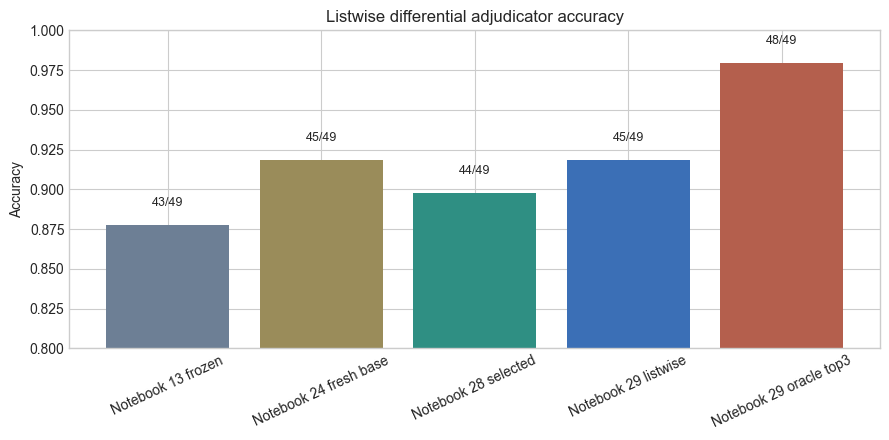

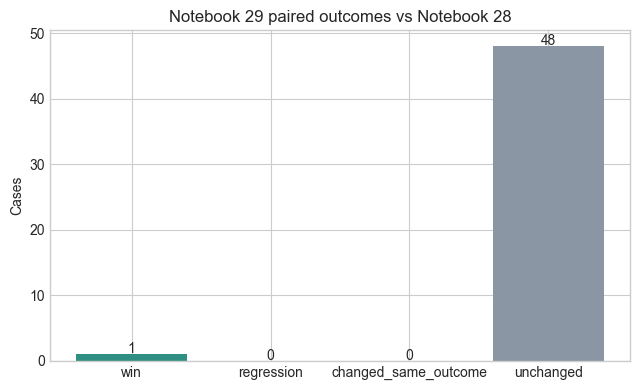

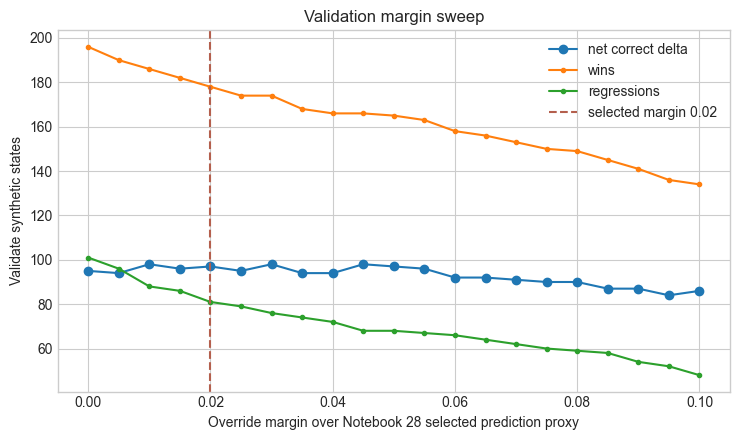

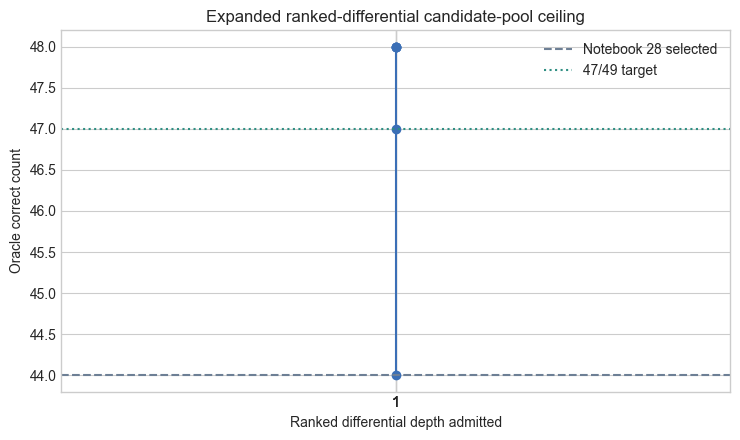

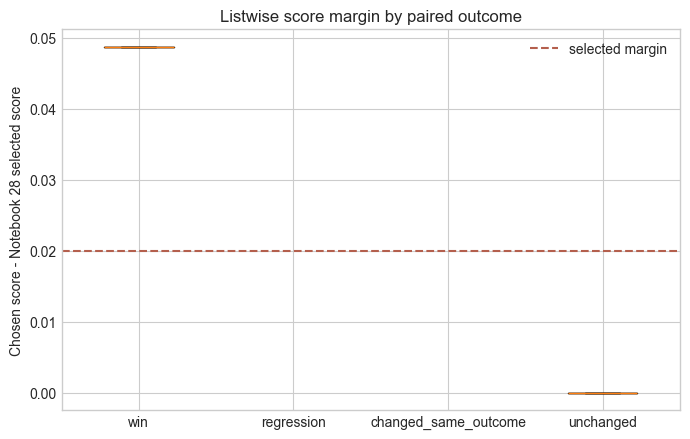

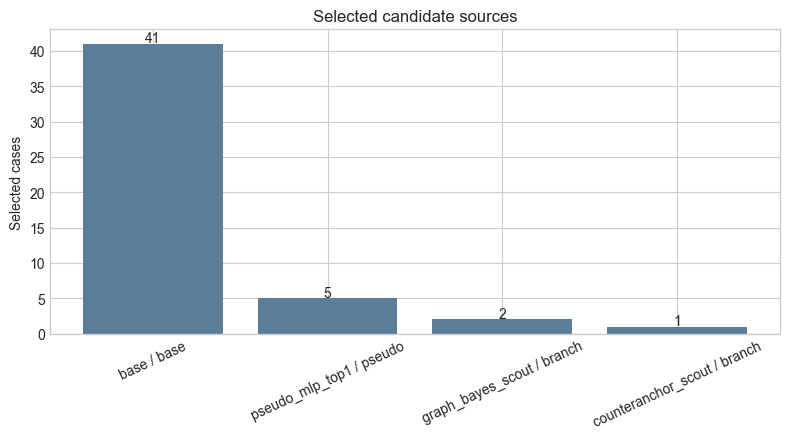

Figures written: ['accuracy_comparison.png', 'candidate_pool_oracle_ceiling.png', 'paired_outcomes.png', 'score_margin_by_outcome.png', 'selected_candidate_sources.png', 'validation_margin_sweep.png']


In [9]:
plt.style.use("seaborn-v0_8-whitegrid")

# Accuracy comparison.
accuracy_rows = [
    {"system": "Notebook 13 frozen", "correct": int(notebook13_predictions["correct"].sum()) if not notebook13_predictions.empty else 43, "num_cases": 49},
    {"system": "Notebook 24 fresh base", "correct": int(notebook24_metrics.get("base_num_correct", notebook24_metrics.get("num_correct", 45))) if notebook24_metrics else 45, "num_cases": 49},
    {"system": "Notebook 28 selected", "correct": int(notebook28_metrics["num_correct"]), "num_cases": int(notebook28_metrics["num_cases"])},
    {"system": "Notebook 29 listwise", "correct": int(selected_summary["correct_count"]), "num_cases": int(selected_summary["num_cases"])},
    {"system": "Notebook 29 oracle top3", "correct": int(oracle_summary.loc[oracle_summary["candidate_pool"] == "source_top1_plus_ranked_top3", "correct_count"].iloc[0]), "num_cases": 49},
]
accuracy_frame = pd.DataFrame(accuracy_rows)
accuracy_frame["accuracy"] = accuracy_frame["correct"] / accuracy_frame["num_cases"]
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#6D7F95", "#9A8C5A", "#2F8F83", "#3B6FB6", "#B45F4D"]
ax.bar(accuracy_frame["system"], accuracy_frame["accuracy"], color=colors)
for idx, row in accuracy_frame.iterrows():
    ax.text(idx, row["accuracy"] + 0.01, f'{int(row["correct"])}/{int(row["num_cases"])}', ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.80, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Listwise differential adjudicator accuracy")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "accuracy_comparison.png", dpi=180)
plt.show()

# Paired outcomes.
paired_counts = paired["paired_outcome"].value_counts().reindex(["win", "regression", "changed_same_outcome", "unchanged"], fill_value=0)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(paired_counts.index, paired_counts.values, color=["#2F8F83", "#B45F4D", "#C49A3A", "#8A96A3"])
ax.set_ylabel("Cases")
ax.set_title("Notebook 29 paired outcomes vs Notebook 28")
for idx, value in enumerate(paired_counts.values):
    ax.text(idx, value + 0.2, str(int(value)), ha="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "paired_outcomes.png", dpi=180)
plt.show()

# Validation margin sweep.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(margin_sweep["margin"], margin_sweep["delta"], marker="o", label="net correct delta")
ax.plot(margin_sweep["margin"], margin_sweep["wins"], marker=".", label="wins")
ax.plot(margin_sweep["margin"], margin_sweep["regressions"], marker=".", label="regressions")
ax.axvline(SELECTED_MARGIN, color="#B45F4D", linestyle="--", label=f"selected margin {SELECTED_MARGIN}")
ax.set_xlabel("Override margin over Notebook 28 selected prediction proxy")
ax.set_ylabel("Validate synthetic states")
ax.set_title("Validation margin sweep")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_margin_sweep.png", dpi=180)
plt.show()

# Oracle ceiling.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_oracle = oracle_summary[oracle_summary["candidate_pool"].str.contains("ranked_top")].copy()
plot_oracle["top_k"] = plot_oracle["candidate_pool"].str.extract(r"top(\d+)").astype(int)
ax.plot(plot_oracle["top_k"], plot_oracle["correct_count"], marker="o", color="#3B6FB6")
ax.axhline(int(notebook28_metrics["num_correct"]), color="#6D7F95", linestyle="--", label="Notebook 28 selected")
ax.axhline(PROMOTION_MIN_CORRECT, color="#2F8F83", linestyle=":", label="47/49 target")
ax.set_xticks(plot_oracle["top_k"])
ax.set_xlabel("Ranked differential depth admitted")
ax.set_ylabel("Oracle correct count")
ax.set_title("Expanded ranked-differential candidate-pool ceiling")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "candidate_pool_oracle_ceiling.png", dpi=180)
plt.show()

# Score margin by paired outcome.
selected_plot = selected_results.copy()
base_scores = []
for case_id, group in live_candidates.groupby("case_id"):
    base_prediction = base_prediction_by_case[case_id]
    base_rows = group[group["candidate_pathology"] == base_prediction]
    base_scores.append({"case_id": case_id, "base_score": float(base_rows["listwise_score_v1"].max()) if not base_rows.empty else np.nan})
base_score_frame = pd.DataFrame(base_scores)
selected_plot = selected_plot.merge(base_score_frame, on="case_id", how="left")
selected_plot["score_margin_over_notebook28"] = selected_plot["listwise_score_v1"] - selected_plot["base_score"]
selected_plot = selected_plot.merge(paired[["case_id", "paired_outcome"]], on="case_id", how="left")
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["win", "regression", "changed_same_outcome", "unchanged"]
values = [selected_plot.loc[selected_plot["paired_outcome"] == item, "score_margin_over_notebook28"].dropna().to_numpy() for item in order]
ax.boxplot(values, labels=order, showfliers=True)
ax.axhline(SELECTED_MARGIN, color="#B45F4D", linestyle="--", label="selected margin")
ax.set_ylabel("Chosen score - Notebook 28 selected score")
ax.set_title("Listwise score margin by paired outcome")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "score_margin_by_outcome.png", dpi=180)
plt.show()

# Candidate source counts for selected rows.
source_counts = selected_results.assign(source=lambda df: df["branch_id"] + " / " + df["candidate_role"]) ["source"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(source_counts.index, source_counts.values, color="#5A7D9A")
ax.set_ylabel("Selected cases")
ax.set_title("Selected candidate sources")
ax.tick_params(axis="x", rotation=25)
for idx, value in enumerate(source_counts.values):
    ax.text(idx, value + 0.2, str(int(value)), ha="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "selected_candidate_sources.png", dpi=180)
plt.show()

# Hard-case rank movement table as figure-adjacent CSV.
hard_rank_movement = selected_results[selected_results["case_id"].isin(hard_case_ids)][
    [
        "case_id",
        "true_pathology",
        "notebook28_prediction",
        "candidate_pathology",
        "branch_id",
        "candidate_role",
        "differential_rank",
        "candidate_graph_rank",
        "candidate_bayes_rank",
        "candidate_mlp_rank",
        "listwise_score_v1",
        "policy_correct",
    ]
].copy()
hard_rank_movement.to_csv(ARTIFACT_ROOT / "hard_case_rank_movement.csv", index=False)
print("Figures written:", sorted(path.name for path in FIGURE_DIR.glob("*.png")))

## 9. Final Summary And Artifact Contract

In [10]:
wins = int(selected_summary["wins_vs_notebook28"])
regressions = int(selected_summary["regressions_vs_notebook28"])
correct_count = int(selected_summary["correct_count"])
promotion_decision = (
    "promote_offline_candidate_pending_live_confirmation"
    if correct_count >= PROMOTION_MIN_CORRECT and regressions <= PROMOTION_MAX_REGRESSIONS
    else "not_promoted_diagnostic_offline_listwise_candidate"
)

selected_policy = {
    "policy_name": SELECTED_POLICY_NAME,
    "selected_before_49case_labels_in_this_notebook": True,
    "policy_type": "offline final adjudicator over frozen Notebook 28 live traces",
    "inputs_used_for_training_or_calibration": [
        "Notebook 28 train/validate synthetic candidate resolver features",
        "Notebook 16 train-derived graph evidence weights",
        "Notebook 19 train-derived Bayesian likelihood tables",
        "Notebook 10 partial-evidence MLP checkpoint",
    ],
    "inputs_used_for_49case_scoring": [
        "Notebook 28 live branch traces and ranked differentials",
        "visible evidence only for each branch state",
        "graph/Bayes/MLP scores recomputed from visible evidence",
    ],
    "feature_columns": FEATURE_COLUMNS,
    "selected_margin": SELECTED_MARGIN,
    "eligible_ranked_differential_depth": 3,
    "candidate_auc_validate": float(validation_summary["candidate_auc"].iloc[0]),
    "candidate_average_precision_validate": float(validation_summary["candidate_average_precision"].iloc[0]),
    "notebook28_correct_count": int(selected_summary["notebook28_correct_count"]),
    "selected_correct_count": correct_count,
    "wins_vs_notebook28": wins,
    "regressions_vs_notebook28": regressions,
    "changed_predictions": int(selected_summary["changed_predictions"]),
    "mean_selected_requests": float(selected_summary["mean_selected_requests"]),
    "mean_total_branch_requests": float(selected_summary["mean_total_branch_requests"]),
    "promotion_min_correct": PROMOTION_MIN_CORRECT,
    "promotion_max_regressions": PROMOTION_MAX_REGRESSIONS,
    "promotion_decision": promotion_decision,
    "leakage_guard": "49-case labels are used only for final metrics, paired error analysis, and oracle diagnostics; the selected model and margin are fixed from train/validate artifacts.",
}
(ARTIFACT_ROOT / "selected_listwise_policy.json").write_text(json.dumps(selected_policy, indent=2, ensure_ascii=True))

run_config = {
    "notebook": "29_listwise_differential_graph_bayes_adjudicator.ipynb",
    "run_name": RUN_NAME,
    "artifact_root": str(ARTIFACT_ROOT),
    "created_unix_time": time.time(),
    "selected_policy_name": SELECTED_POLICY_NAME,
    "selected_margin": SELECTED_MARGIN,
    "promotion_decision": promotion_decision,
    "input_roots": {
        "notebook28_root": str(NOTEBOOK28_ROOT),
        "notebook13_root": str(NOTEBOOK13_ROOT),
        "notebook24_root": str(NOTEBOOK24_ROOT),
        "graph_root": str(GRAPH_ROOT),
        "bayes_root": str(BAYES_ROOT),
        "partial_mlp_root": str(PARTIAL_MLP_ROOT),
        "dataset_root": str(DATASET_ROOT),
    },
    "no_api_calls": True,
}
(ARTIFACT_ROOT / "resolved_run_config.json").write_text(json.dumps(run_config, indent=2, ensure_ascii=True))

required_outputs = [
    "resolved_run_config.json",
    "listwise_candidate_train_validate_features.csv",
    "listwise_validation_summary.csv",
    "listwise_validation_margin_sweep.csv",
    "listwise_live_candidate_scores.csv",
    "listwise_policy_summary.csv",
    "case_level_listwise_results.csv",
    "paired_notebook28_vs_listwise.csv",
    "candidate_pool_oracle_summary.csv",
    "hard_case_listwise_audits.json",
    "selected_listwise_policy.json",
    "hard_case_rank_movement.csv",
]
artifact_contract = pd.DataFrame(
    [{"path": name, "exists": (ARTIFACT_ROOT / name).exists(), "bytes": (ARTIFACT_ROOT / name).stat().st_size if (ARTIFACT_ROOT / name).exists() else 0} for name in required_outputs]
)
artifact_contract.to_csv(ARTIFACT_ROOT / "artifact_contract_check.csv", index=False)

print("Promotion decision:", promotion_decision)
print("Selected policy:", correct_count, "/", int(selected_summary["num_cases"]), "wins", wins, "regressions", regressions)
display(artifact_contract)

Promotion decision: not_promoted_diagnostic_offline_listwise_candidate
Selected policy: 45 / 49 wins 1 regressions 0


,path,exists,bytes
0,resolved_run_config.json,True,1495
1,listwise_candidate_train_validate_features.csv,True,13293520
2,listwise_validation_summary.csv,True,219
3,listwise_validation_margin_sweep.csv,True,1253
4,listwise_live_candidate_scores.csv,True,419129
5,listwise_policy_summary.csv,True,1156
6,case_level_listwise_results.csv,True,36222
7,paired_notebook28_vs_listwise.csv,True,7239
8,candidate_pool_oracle_summary.csv,True,475
9,hard_case_listwise_audits.json,True,23276
